In [2]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import Counter, deque
from skimage.io import imread
from skimage.measure import regionprops
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment, curve_fit
import cellpose.core
from cellpose import models

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

In [3]:

# --- Build the lineage graph (same as before) ---
def build_lineage_graph(tracks):
    G = nx.DiGraph()
    for t in tracks:
        c_label = int(t['curr_frame_label'])
        f = int(t['frame'])
        G.add_node((c_label, f), label=c_label, frame=f)

        p_label = t['prev_frame_label']
        if p_label is not None:
            p_label = int(p_label)
            G.add_node((p_label, f-1), label=p_label, frame=f-1)
            G.add_edge((p_label, f-1), (c_label, f))
    return G

# --- Split into trees (one per root) ---
def lineage_forest(G):
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    # Extract a weakly-connected component around each root as a tree
    # (Graph is a DAG by construction.)
    trees = []
    seen = set()
    for r in roots:
        comp = set(nx.descendants(G, r)) | {r}
        # Avoid duplicates if multiple roots share descendants (shouldn't happen)
        if comp & seen:
            continue
        seen |= comp
        T = G.subgraph(comp).copy()
        trees.append((r, T))
    return trees

# --- Compute generations (depth) from the root ---
def generations_from_root(T, root):
    depth = {root: 0}
    q = deque([root])
    while q:
        u = q.popleft()
        for v in T.successors(u):
            depth[v] = depth[u] + 1
            q.append(v)
    return depth

# --- Tidy tree layout (DFS order -> x positions; depth -> y positions) ---
def tidy_tree_layout(T, root, y_gap=1.5, x_gap=1.0):
    """
    Returns a dict pos[(label, frame)] = (x, y) with root at top, children below.
    x positions assigned by DFS leaf-order (compact, non-overlapping).
    """
    depth = generations_from_root(T, root)

    children = {u: sorted(list(T.successors(u)), key=lambda v: (depth[v], T.nodes[v]['label'], v))
                for u in T.nodes}
    # Order nodes by frame then label for consistent traversal
    for u in children:
        children[u].sort(key=lambda v: (depth[v], T.nodes[v]['frame'], T.nodes[v]['label']))

    pos = {}
    x_counter = [0]  # mutable counter captured by closure

    def assign_x(u):
        # Leaf -> get next x slot
        if len(children[u]) == 0:
            x = x_counter[0]
            x_counter[0] += 1
            return x
        # Internal: average of children's x
        xs = [assign_x(v) for v in children[u]]
        return sum(xs) / len(xs)

    # First pass to get root x (and implicitly all children)
    root_x = assign_x(root)

    # Second pass to collect all x (re-run but record)
    x_counter[0] = 0
    x_map = {}

    def place(u):
        if len(children[u]) == 0:
            x = x_counter[0]
            x_counter[0] += 1
        else:
            xs = []
            for v in children[u]:
                xs.append(place(v))
            x = sum(xs) / len(xs)
        x_map[u] = x
        return x

    place(root)

    # Scale and set y by generation (root on top: smallest y)
    for u, x in x_map.items():
        y = -depth[u] * y_gap  # downward
        pos[u] = (x * x_gap, y)

    return pos

# --- Plot a forest as stacked trees ---
def plot_lineage_as_trees(tracks, node_size=600, with_labels=True, figsize=(20, 10), tree_gap=5.0):
    G = build_lineage_graph(tracks)
    if G.number_of_nodes() == 0:
        print("No nodes to plot.")
        return

    forest = lineage_forest(G)
    if not forest:
        print("No roots found; cannot render trees.")
        return

    # Build combined positions, offsetting each tree horizontally
    combined_pos = {}
    x_offset = 1.0
    all_edges = []
    all_nodes = set()

    for root, T in forest:
        pos = tidy_tree_layout(T, root)
        # shift x by current offset
        shifted = {n: (p[0] + x_offset, p[1]) for n, p in pos.items()}
        combined_pos.update(shifted)

        all_edges.extend(list(T.edges()))
        all_nodes |= set(T.nodes())

        # compute width of this tree to set the next offset
        xs = [p[0] for p in pos.values()]
        width = (max(xs) - min(xs)) if xs else 0.0
        x_offset += width + tree_gap

    return G

In [4]:
def extract_run_analysis(directory,s,d):

    img_stack=[]
    files=os.listdir(directory)
    for i in range(1,48):
        file_loc=directory+"yPN_s"+str(s)+"_t"+str(i)+".TIF"
        img_stack.append(imread(file_loc).astype('int16'))

    file = np.stack(img_stack)

    num_cells=[]
    masks=[]
    for i in range(len(file)):
        masks_zero, flows, diams = model.eval(file[i], diameter=50)
        num_cells.append(masks_zero.max())
        masks.append(masks_zero)
        
    masks_arr=np.array(masks)[:,0:1120,0:1120]
    
    fa=[]
    for j in range(int(masks_arr.shape[1]/d)):
        for k in range(int(masks_arr.shape[2]/d)):
            sub_mask=masks_arr[:,(d*j):d*(j+1),(d*k):d*(k+1)]
            fa.append(track_sub_mask(sub_mask[0:49,:,:],100,10))

    return np.nanmean(fa)

In [5]:
def track_sub_mask(sub_mask_input,dist_thresh,pen_child):

    
    all_properties = []
    for frame_idx, mask in enumerate(sub_mask_input):
        properties = regionprops(mask)
        for prop in properties:
            all_properties.append({
                'frame': frame_idx,
                'label': prop.label,
                'centroid': prop.centroid,
                'area': prop.area,
                'bbox': prop.bbox,
                'radius': prop.feret_diameter_max
            })

    properties_df = pd.DataFrame(all_properties)

    tracks = []

    distance_threshold = dist_thresh         # pixels: cap/clip costs for implausible links
    L = 2                           # max children per parent (L=2 for binary division)
    lam_extra_child = pen_child         # penalty for each extra child (beyond first) per parent
    alpha_disappear = 100.0          # penalty if a parent uses its (i,1) dummy (i.e., disappears)
    beta_birth = 1000.0               # penalty to explain a child as a "new birth"
    large_cost = 1e6                # sentinel for impossible matches

    for i in range(1, len(sub_mask_input)):
        prev_frame_props = properties_df[properties_df['frame'] == i - 1].reset_index(drop=True)
        curr_frame_props = properties_df[properties_df['frame'] == i].reset_index(drop=True)

        if curr_frame_props.empty:
            continue

        if prev_frame_props.empty:
            for _, row in curr_frame_props.iterrows():
                tracks.append({'prev_frame_label': None, 'curr_frame_label': row['label'], 'frame': i})
            continue

        prev_centroids = np.vstack(prev_frame_props['centroid'].to_numpy())
        curr_centroids = np.vstack(curr_frame_props['centroid'].to_numpy())
        base_D = cdist(prev_centroids, curr_centroids)  # shape m x n

        base_D = np.where(base_D <= distance_threshold, base_D, large_cost)

        m = prev_frame_props.shape[0]
        n = curr_frame_props.shape[0]


        num_rows = m * L + n
        num_cols = n + m * L
        assert num_rows == num_cols, "Matrix should be square"

        C = np.full((num_rows, num_cols), large_cost, dtype=float)

        def row_is_parent(r): return r < m * L
        def parent_idx(r):     return r // L
        def cap_slot(r):       return (r % L) + 1  # 1..L

        def col_is_child(c):   return c < n
        # capacity dummies are columns [n .. n + m*L - 1]
        def dummy_col_for(parent_r): return n + parent_r  # one dummy per capacity row

        for r in range(m * L):
            i_parent = parent_idx(r)
            ell = cap_slot(r)
            extra = 0.0 if ell == 1 else lam_extra_child
            C[r, :n] = base_D[i_parent, :] + extra

            dc = dummy_col_for(r)

            C[r, dc] = alpha_disappear if ell == 1 else 0.0

        for b in range(n):
            r = m * L + b  # birth row index
            C[r, :n] = beta_birth
            C[r, n:] = 0.0

        row_ind, col_ind = linear_sum_assignment(C)

        children_per_parent = {int(prev_frame_props.iloc[p]['label']): 0 for p in range(m)}

        child_labels = curr_frame_props['label'].to_numpy()
        parent_labels = prev_frame_props['label'].to_numpy()

        for r, c in zip(row_ind, col_ind):
            if row_is_parent(r) and col_is_child(c):
                i_parent = parent_idx(r)
                p_label = int(parent_labels[i_parent])
                c_label = int(child_labels[c])
                # If cost was large (distance > threshold), skip (treat as not a valid link)
                if C[r, c] >= large_cost * 0.5:
                    continue
                tracks.append({'prev_frame_label': p_label,
                               'curr_frame_label': c_label,
                               'frame': i})
                children_per_parent[p_label] += 1
            elif (not row_is_parent(r)) and col_is_child(c):
                c_label = int(child_labels[c])
                if C[r, c] >= large_cost * 0.5:
                    continue
                tracks.append({'prev_frame_label': None,
                               'curr_frame_label': c_label,
                               'frame': i})
    
    G=plot_lineage_as_trees(tracks)
    
    # Get the lineage forest to find the roots
    growth_slope=[]
    ids=[]
    forest = lineage_forest(G)

    for f in forest:

        root, tree = f

        if(root[1]==0):
            # Get the generations (depth) from this root
            depths = generations_from_root(tree, root)
            ids.append(root[0])
            growth_slope.append(np.mean(np.gradient(list(Counter(depths.values()).values()),list(Counter(depths.values()).keys()))))
    
    if (len(growth_slope)!=0):
        fa=sum(np.array(growth_slope)==0)/len(growth_slope)
    else: 
        fa=np.nan
    return fa

In [6]:
cellpose.core.use_gpu()

True

In [7]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

model_type argument is not used in v4.0.1+. Ignoring this argument...


In [8]:
directory="/n/murraylab/Users/pnanda/DCS/Manuscript/Repeat_3plicates/"

fa_vals_rep1=[]

s_rep1=np.arange(1,22,1)

for s in s_rep1:
    fa_vals_rep1.append(extract_run_analysis(directory,s,500))


In [9]:
fa_vals_rep1

[np.float64(0.6791062244082692),
 np.float64(0.6942355889724311),
 np.float64(0.7745354078834037),
 np.float64(0.6122222222222222),
 np.float64(0.5762648809523809),
 np.float64(0.657184829059829),
 np.float64(0.7691365007541479),
 np.float64(0.7091991341991343),
 np.float64(0.6833333333333333),
 np.float64(0.5406741108354012),
 np.float64(0.5300148221343873),
 np.float64(0.6362573099415205),
 np.float64(0.6739775489775489),
 np.float64(0.6531503036437247),
 np.float64(0.7258530565560695),
 np.float64(0.5276915113871635),
 np.float64(0.40653935185185186),
 np.float64(0.43210028050490884),
 np.float64(0.6895833333333334),
 np.float64(0.5608187134502924),
 np.float64(0.668609022556391)]

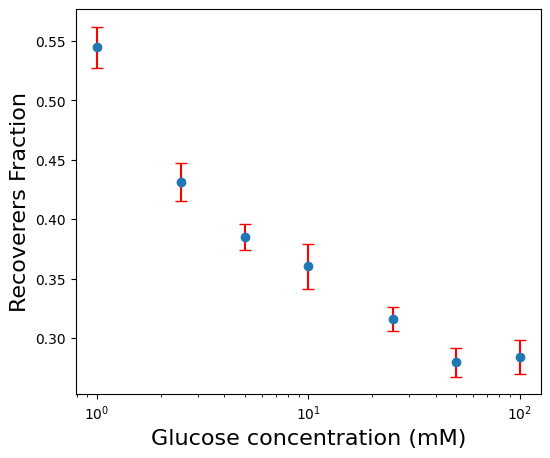

In [10]:
fa_vals_arr=np.array(fa_vals_rep1).reshape(7,3)[[0,2,4,6,1,3,5]]

x = np.array([100, 50, 25, 10, 5, 2.5, 1])
y = 1 - fa_vals_arr.mean(axis=1)
yerr = fa_vals_arr.std(axis=1)/3  # Example: standard deviation as error
plt.figure(figsize=(6,5))
plt.errorbar(x, y, yerr=yerr, fmt='o', ecolor='red', capsize=4)
plt.xlabel('Glucose concentration (mM)',fontsize=16)
plt.ylabel('Recoverers Fraction',fontsize=16)
plt.xscale('log',base=10)
plt.show()

In [11]:
directory="/n/murraylab/Users/pnanda/DCS/Manuscript/Repeat_3plicates/"

fa_vals_rep2=[]

s_rep2=np.arange(25,46,1)

for s in s_rep2:
    fa_vals_rep2.append(extract_run_analysis(directory,s,500))


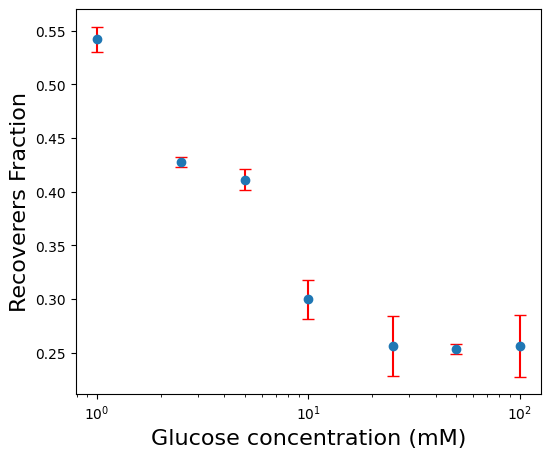

In [12]:
fa_vals_arr=np.array(fa_vals_rep2).reshape(7,3)[[0,2,4,6,1,3,5]]

x = np.array([100, 50, 25, 10, 5, 2.5, 1])
y = 1 - fa_vals_arr.mean(axis=1)
yerr = fa_vals_arr.std(axis=1)/3  # Example: standard deviation as error
plt.figure(figsize=(6,5))
plt.errorbar(x, y, yerr=yerr, fmt='o', ecolor='red', capsize=4)
plt.xlabel('Glucose concentration (mM)',fontsize=16)
plt.ylabel('Recoverers Fraction',fontsize=16)
plt.xscale('log',base=10)
plt.show()

In [13]:
directory="/n/murraylab/Users/pnanda/DCS/Manuscript/Repeat_3plicates/"

fa_vals_rep3=[]

s_rep3=np.arange(49,70,1)

for s in s_rep3:
    fa_vals_rep3.append(extract_run_analysis(directory,s,500))


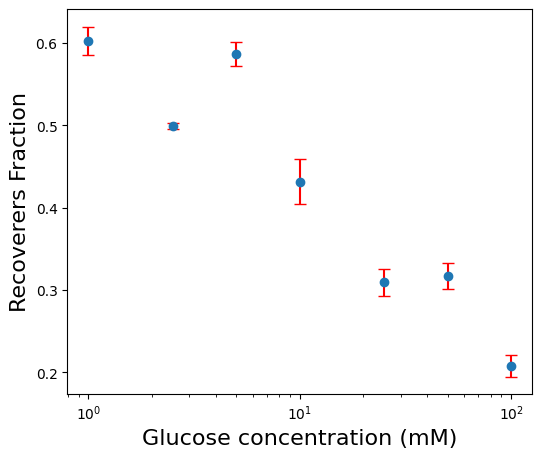

In [14]:
fa_vals_arr=np.array(fa_vals_rep3).reshape(7,3)[[0,2,4,6,1,3,5]]

x = np.array([100, 50, 25, 10, 5, 2.5, 1])
y = 1 - fa_vals_arr.mean(axis=1)
yerr = fa_vals_arr.std(axis=1)/3  # Example: standard deviation as error
plt.figure(figsize=(6,5))
plt.errorbar(x, y, yerr=yerr, fmt='o', ecolor='red', capsize=4)
plt.xlabel('Glucose concentration (mM)',fontsize=16)
plt.ylabel('Recoverers Fraction',fontsize=16)
plt.xscale('log',base=10)
plt.show()

In [16]:
fa_vals_arr1=np.array(fa_vals_rep1).reshape(7,3)[[0,2,4,6,1,3,5]]
fa_vals_arr2=np.array(fa_vals_rep2).reshape(7,3)[[0,2,4,6,1,3,5]]
fa_vals_arr3=np.array(fa_vals_rep3).reshape(7,3)[[0,2,4,6,1,3,5]]

fa_vals_arr=np.median([fa_vals_arr1,fa_vals_arr2,fa_vals_arr3],axis=0)

In [17]:
fa_vals_arr_save=np.array([fa_vals_arr1,fa_vals_arr2,fa_vals_arr3])

In [18]:
np.save('glucose_gradient_full_data',fa_vals_arr_save)

In [19]:
fa_vals_arr_raw=np.load('glucose_gradient_full_data.npy')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

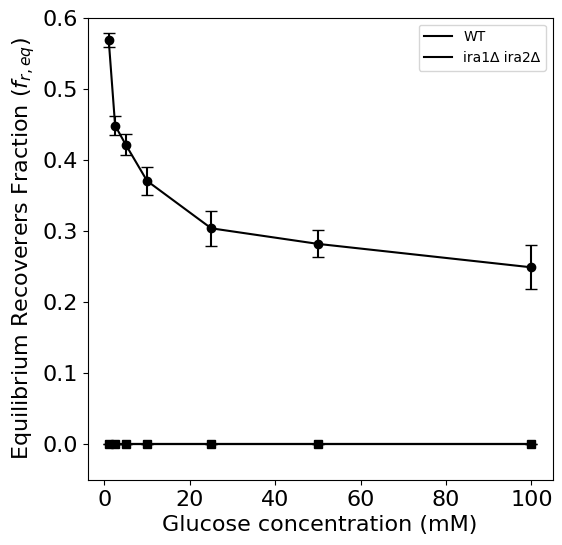

In [20]:
fa_vals_arr1=fa_vals_arr_raw[0]
fa_vals_arr2=fa_vals_arr_raw[1]
fa_vals_arr3=fa_vals_arr_raw[2]

fa_vals_arr=np.median(fa_vals_arr_raw,axis=0)

x = np.array([100, 50, 25, 10, 5, 2.5, 1])
y =  1-fa_vals_arr.mean(axis=1)
yerr = fa_vals_arr.std(axis=1)/np.sqrt(3)  
y_ira=np.zeros(shape=(7,3))
yerr_ira = y_ira.std(axis=1)/np.sqrt(3)
# plt.rcParams['font.sans-serif'] = ['Helvetica']

# plt.rc('font',family='Helvetica')
plt.figure(figsize=(6,6))
plt.errorbar(x, y, yerr=yerr, fmt='o', color='black', capsize=4)
plt.errorbar(x, y_ira.mean(axis=1), yerr=yerr_ira, fmt='s', color='black', capsize=4)
plt.plot(x,y,color='black',linestyle='-')
plt.plot(x,y_ira,color='black')
# plt.scatter(x,fa_vals_arr1.mean(axis=1),color='k')
# plt.scatter(x,fa_vals_arr2.mean(axis=1),color='k')
# plt.scatter(x,fa_vals_arr3.mean(axis=1),color='k')

plt.xlabel('Glucose concentration (mM)',fontsize=16)
plt.ylabel(r'Equilibrium Recoverers Fraction ($f_{r,eq}$)',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(['WT','ira1∆ ira2∆'])
# plt.xscale('log',base=2)
plt.ylim(-0.05,0.6)

import matplotlib as mpl
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it

plt.savefig("Glucose_response_Equilibrium_Fraction.svg", format="svg", bbox_inches="tight")